# 12-statement-forest
## Ответ: 21

In [34]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

In [35]:
data = pd.read_csv('abalone.csv')

In [36]:
data.head()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [37]:
data['Sex'] = data['Sex'].map(lambda x: 1 if x == 'M' else (-1 if x == 'F' else 0))

In [38]:
data.head()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,1,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,-1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,1,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,0,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [39]:
X = data.iloc[:, :-1]
X.head()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight
0,1,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,-1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,1,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,0,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [43]:
y = data.iloc[:, -1]
y.head()

0    15
1     7
2     9
3    10
4     7
Name: Rings, dtype: int64

21


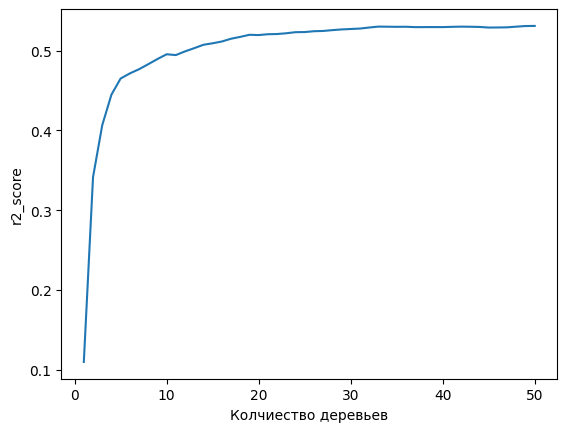

In [44]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
results = []
n_arr = [j for j in range(1, 51)]
r2_score_best = 0.52
n_min = 50

for n in range (1, 51):
    clf = RandomForestRegressor(n_estimators=n, random_state=1)
    scores = cross_val_score(clf, X, y, cv=kf, scoring='r2').mean()
    results.append(scores)

    if scores > r2_score_best and n < n_min:
        n_min = n
print(n_min)

plt.plot(n_arr, results)   
plt.xlabel('Колчиество деревьев')
plt.ylabel('r2_score')

plt.show()
    

